In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
from pathlib import Path
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks
from sklearn.model_selection import GroupKFold

In [2]:
# =====================================================================
# CELL 3 — REPLACE: Load data with demographics (H&Y + weight)
# =====================================================================
col_names = ['Time',
             'L1','L2','L3','L4','L5','L6','L7','L8',
             'R1','R2','R3','R4','R5','R6','R7','R8',
             'L_Total','R_Total']

def load_gait_data(data_dir, demographics_path):
    """Load all gait files and merge with demographic data."""
    demo = pd.read_excel(demographics_path)
    demo_dict = demo.set_index('ID').to_dict('index')

    records = []
    for filepath in Path(data_dir).glob('*.txt'):
        filename = filepath.stem

        if 'Co' in filename:
            label = 0
        elif 'Pt' in filename:
            label = 1
        else:
            continue

        walk_num = filename.split('_')[1]
        dual_task = 1 if walk_num == '10' else 0
        subject_id = filename.split('_')[0]

        data = pd.read_csv(filepath, sep='\t', header=None, names=col_names)

        record = {
            'filename': filename,
            'subject_id': subject_id,
            'label': label,
            'dual_task': dual_task,
            'L_Total': data['L_Total'].values,
            'R_Total': data['R_Total'].values,
        }

        if subject_id in demo_dict:
            d = demo_dict[subject_id]
            record['weight_kg'] = d.get('Weight (kg)')
            record['hoehn_yahr'] = d.get('HoehnYahr')
            record['updrs'] = d.get('UPDRS')
        else:
            record.update({'weight_kg': None, 'hoehn_yahr': None, 'updrs': None})

        records.append(record)

    return records

# --- UPDATE THESE PATHS FOR YOUR MACHINE ---
data_dir = 'C:/Users/simon/PycharmProjects/ParkinsonsDetection/gait-in-parkinsons-disease-1.0.0'
demographics_path = ('C:/Users/simon/PycharmProjects/ParkinsonsDetection/gait-in-parkinsons-disease-1.0.0/demographics.xls')
all_data = load_gait_data(data_dir, demographics_path)

# Set control clinical scores to 0
for record in all_data:
    if record['label'] == 0:
        for key in ['hoehn_yahr', 'updrs']:
            if record[key] is None or pd.isna(record[key]):
                record[key] = 0

# Map H&Y values to class indices: Control=0, H&Y2.0=1, H&Y2.5=2, H&Y3.0=3
HY_CLASS_MAP = {0: 0, 2: 1, 2.5: 2, 3: 3}
HY_CLASS_NAMES = {0: 'Control', 1: 'H&Y 2.0', 2: 'H&Y 2.5', 3: 'H&Y 3.0'}
NUM_CLASSES = 4

# Filter out subjects with missing weight or unmapped H&Y values
valid_data = []
skipped_hy = set()
for record in all_data:
    hy = record['hoehn_yahr']
    w = record['weight_kg']

    if w is None or pd.isna(w):
        continue
    if hy not in HY_CLASS_MAP:
        skipped_hy.add(hy)
        continue

    record['hy_class'] = HY_CLASS_MAP[hy]
    valid_data.append(record)

print(f"Loaded {len(all_data)} recordings, {len(valid_data)} with valid weight + H&Y")
if skipped_hy:
    print(f"  Skipped H&Y values not in map: {skipped_hy}")
for cls_idx, cls_name in HY_CLASS_NAMES.items():
    n = sum(1 for d in valid_data if d['hy_class'] == cls_idx)
    print(f"  {cls_name}: {n} recordings")

Loaded 306 recordings, 301 with valid weight + H&Y
  Control: 91 recordings
  H&Y 2.0: 109 recordings
  H&Y 2.5: 80 recordings
  H&Y 3.0: 21 recordings


In [3]:
SAMPLING_RATE = 100  # Hz
FORCE_THRESHOLD = 50  # N

def detect_stance_phases(force_signal, threshold=FORCE_THRESHOLD):
    """Detect stance phases from a total force signal.
    Returns list of (onset_idx, offset_idx) tuples."""
    is_stance = force_signal > threshold
    diff = np.diff(is_stance.astype(int))

    onsets = np.where(diff == 1)[0] + 1
    offsets = np.where(diff == -1)[0] + 1

    if is_stance[0]:
        onsets = np.insert(onsets, 0, 0)
    if is_stance[-1]:
        offsets = np.append(offsets, len(force_signal))

    n = min(len(onsets), len(offsets))
    phases = [(onsets[i], offsets[i]) for i in range(n)
              if offsets[i] > onsets[i]]

    min_samples = int(0.2 * SAMPLING_RATE)
    max_samples = int(2.5 * SAMPLING_RATE)
    phases = [(on, off) for on, off in phases
              if (off - on) >= min_samples and (off - on) <= max_samples]

    return phases

def classify_cycle(stance_waveform, prominence=20, valley_depth_pct=0.0):
    """Classify a single stance waveform as M-shape or not.
    Returns True if M-shape: 2+ peaks with sufficient prominence
    AND a valley that dips at least valley_depth_pct below the lower peak."""
    min_dist = max(int(0.3 * len(stance_waveform)), 1)
    peaks, _ = find_peaks(stance_waveform, distance=min_dist, prominence=prominence)

    if len(peaks) < 2:
        return False

    # Check valley depth between first and last peak
    f1 = stance_waveform[peaks[0]]
    f2 = stance_waveform[peaks[-1]]
    valley = np.min(stance_waveform[peaks[0]:peaks[-1] + 1])
    lower_peak = min(f1, f2)

    # Valley must dip by at least valley_depth_pct below the lower peak
    return valley <= lower_peak * (1 - valley_depth_pct)

def compute_window_mshape_pct(r_window, l_window):
    """For a single window, detect stance cycles in both feet
    and return the % of cycles that are M-shaped."""
    total_cycles = 0
    mshape_cycles = 0

    for signal in [r_window, l_window]:
        phases = detect_stance_phases(signal)
        for onset, offset in phases:
            stance = signal[onset:offset]
            total_cycles += 1
            if classify_cycle(stance):
                mshape_cycles += 1

    if total_cycles == 0:
        return np.nan, total_cycles, mshape_cycles

    return mshape_cycles / total_cycles, total_cycles, mshape_cycles

In [4]:
# =====================================================================
# CELL 5 — Window extraction with quality filtering + rejected tracking
# =====================================================================
WINDOW_LENGTH = 1201
STEP_SIZE = WINDOW_LENGTH // 4

flow_r_row = []
flow_l_row = []
labels_row = []
weights_row = []
subject_ids_row = []

# Track rejected windows for inspection
rejected_r = []
rejected_l = []
rejected_labels = []
rejected_reasons = []

for subject in valid_data:
    r_total = subject['R_Total']
    l_total = subject['L_Total']
    hy_class = subject['hy_class']
    weight_kg = subject['weight_kg']

    if min(r_total) > 0.0:
        continue

    pos = 0
    while pos < len(r_total) - WINDOW_LENGTH:
        zero_mask = r_total[pos:] == 0.0
        if not zero_mask.any():
            break
        first_zero = pos + zero_mask.argmax()

        after_zero = r_total[first_zero:]
        rise_check = after_zero > 10.0
        if not rise_check.any():
            break
        rise_idx = first_zero + rise_check.argmax()

        start = rise_idx - 1
        while start >= 0 and r_total[start] != 0.0:
            start -= 1

        if start < 0:
            break
        if start + WINDOW_LENGTH > len(r_total):
            break

        r_win = r_total[start:start + WINDOW_LENGTH]
        l_win = l_total[start:start + WINDOW_LENGTH]

        pct, _, _ = compute_window_mshape_pct(r_win, l_win)

        # Quality filter: stance phase count
        r_phases = detect_stance_phases(r_win)
        l_phases = detect_stance_phases(l_win)

        if len(r_phases) < 4 or len(l_phases) < 4:
            rejected_r.append(r_win.copy())
            rejected_l.append(l_win.copy())
            rejected_labels.append(hy_class)
            rejected_reasons.append(f'Low phase count (R={len(r_phases)}, L={len(l_phases)})')
            pos = start + STEP_SIZE
            continue

        # Quality filter: stride regularity
        r_durations = [off - on for on, off in r_phases]
        l_durations = [off - on for on, off in l_phases]
        r_median = np.median(r_durations)
        l_median = np.median(l_durations)
        max_difference = 1.7

        if max(r_durations) > max_difference * r_median or max(l_durations) > max_difference * l_median:
            rejected_r.append(r_win.copy())
            rejected_l.append(l_win.copy())
            rejected_labels.append(hy_class)
            r_ratio = max(r_durations) / r_median
            l_ratio = max(l_durations) / l_median
            rejected_reasons.append(f'Irregular stride (R={r_ratio:.1f}x, L={l_ratio:.1f}x median)')
            pos = start + STEP_SIZE
            continue

        if not np.isnan(pct):
            flow_r_row.append(r_win)
            flow_l_row.append(l_win)
            labels_row.append(hy_class)
            weights_row.append(weight_kg)
            subject_ids_row.append(subject['subject_id'])

        pos = start + STEP_SIZE

# Stack into arrays
flow_r = np.stack(flow_r_row)
flow_l = np.stack(flow_l_row)
flow = np.stack([flow_r, flow_l], axis=1)
labels = np.array(labels_row, dtype=np.int64)
weights = np.array(weights_row, dtype=np.float32)
subject_ids = np.array(subject_ids_row)

print(f"\nExtracted {len(flow)} windows, shape: {flow.shape}")
print(f"Rejected {len(rejected_r)} windows")
for cls_idx, cls_name in HY_CLASS_NAMES.items():
    n = (labels == cls_idx).sum()
    n_rej = sum(1 for l in rejected_labels if l == cls_idx)
    print(f"  Class {cls_idx} ({cls_name}): {n} kept, {n_rej} rejected")
print(f"\nWeight range: {weights.min():.1f} – {weights.max():.1f} kg")
n_subjects = len(np.unique(subject_ids))
print(f"Windows come from {n_subjects} unique subjects")
for cls_idx, cls_name in HY_CLASS_NAMES.items():
    cls_mask = labels == cls_idx
    n_sub = len(np.unique(subject_ids[cls_mask]))
    print(f"  {cls_name}: {n_sub} subjects, {cls_mask.sum()} windows")


Extracted 7212 windows, shape: (7212, 2, 1201)
Rejected 886 windows
  Class 0 (Control): 2386 kept, 206 rejected
  Class 1 (H&Y 2.0): 2667 kept, 287 rejected
  Class 2 (H&Y 2.5): 1625 kept, 294 rejected
  Class 3 (H&Y 3.0): 534 kept, 99 rejected

Weight range: 47.0 – 105.0 kg
Windows come from 162 unique subjects
  Control: 71 subjects, 2386 windows
  H&Y 2.0: 55 subjects, 2667 windows
  H&Y 2.5: 27 subjects, 1625 windows
  H&Y 3.0: 9 subjects, 534 windows



## CNN Classifier — Real Data Baseline

A lightweight 1D CNN trained and evaluated on real signals using stratified
k-fold cross-validation. Signals are lowpass-filtered and clipped (identical
to the cGAN post-processing pipeline) so that any future TSTR comparison
uses the same input representation.

In [5]:
# Filter real signals (same pipeline as generated signals)

def lowpass_filter(signal, cutoff=10, fs=100, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, signal)

# Apply same filtering as generated signals: lowpass → clip to 0
real_r_filtered = np.clip(np.array([lowpass_filter(s) for s in flow[:, 0, :]]), 0, None)
real_l_filtered = np.clip(np.array([lowpass_filter(s) for s in flow[:, 1, :]]), 0, None)

# Stack into (N, 2, 1201) — 2-channel input for the CNN
real_filtered = np.stack([real_r_filtered, real_l_filtered], axis=1).astype(np.float32)

print(f"Filtered real data: {real_filtered.shape}")
for cls_idx, cls_name in HY_CLASS_NAMES.items():
    print(f"  {cls_name}: {(labels == cls_idx).sum()}")

Filtered real data: (7212, 2, 1201)
  Control: 2386
  H&Y 2.0: 2667
  H&Y 2.5: 1625
  H&Y 3.0: 534


In [6]:
# Define CNN architecture

class GaitCNN(nn.Module):
    def __init__(self, num_classes=4, in_channels=2, signal_length=1201,
                 base_filters=32, dropout=0.3):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),    # 1201 → 300
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv1d(base_filters, base_filters * 2, kernel_size=5, padding=2),
            nn.BatchNorm1d(base_filters * 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),    # 300 → 75
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv1d(base_filters * 2, base_filters * 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(base_filters * 4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                   # 75 → 1 (global average pool)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base_filters * 4, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.squeeze(-1)          # (batch, base_filters*4)
        x = self.classifier(x)
        return x

# Quick check
_test = GaitCNN()
_out = _test(torch.randn(2, 2, 1201))
total_params = sum(p.numel() for p in _test.parameters())
print(f"Output shape: {_out.shape}")
print(f"Total parameters: {total_params:,}")
del _test, _out

Output shape: torch.Size([2, 4])
Total parameters: 44,452


In [7]:
# Training + evaluation with stratified k-fold CV
# ========================
# HYPERPARAMETERS — tune these
# ========================
NUM_FOLDS = 3
NUM_EPOCHS    = 300

BASE_FILTERS  = 64
BATCH_SIZE    = 64
DROPOUT       = 0.2
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 5e-4
PATIENCE      = 20
# ========================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Class weights for imbalanced data
class_counts = np.bincount(labels, minlength=NUM_CLASSES)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", {HY_CLASS_NAMES[i]: f"{class_weights[i]:.2f}" for i in range(NUM_CLASSES)})

# Normalise per-channel (fit on train fold each time)
def normalise_channels(train_data, test_data):
    """Per-channel zero-mean, unit-std normalisation."""
    mean = train_data.mean(axis=(0, 2), keepdims=True)
    std  = train_data.std(axis=(0, 2), keepdims=True) + 1e-8
    return (train_data - mean) / std, (test_data - mean) / std

# Subject-level splitting — no data leakage between folds
gkf = GroupKFold(n_splits=NUM_FOLDS)

NUM_REPEATS = 10  # or 5 for more stability

repeat_fold_results = []  # flat list of all fold accuracies across all repeats
all_preds_repeats = []    # list of (N,) prediction arrays, one per repeat
all_probs_repeats = []    # list of (N, NUM_CLASSES) arrays, one per repeat

unique_subjects = np.unique(subject_ids)
print(f"\nSplitting by {len(unique_subjects)} unique subjects across {NUM_FOLDS} folds")

for repeat in range(NUM_REPEATS):
    print(f"\n{'#'*60}")
    print(f"# REPEAT {repeat + 1}/{NUM_REPEATS}")
    print(f"{'#'*60}")

    # Re-seed the fold splitter with a different seed each repeat
    gkf = GroupKFold(n_splits=NUM_FOLDS)
    # Shuffle subject-level group assignments so folds change each repeat
    rng = np.random.RandomState(repeat)
    shuffled_groups = subject_ids.copy()
    unique_subs = np.unique(subject_ids)
    permuted = rng.permutation(unique_subs)
    sub_map = dict(zip(unique_subs, permuted))
    shuffled_groups = np.array([sub_map[s] for s in subject_ids])

    all_preds = np.zeros(len(labels), dtype=np.int64)
    all_probs = np.zeros((len(labels), NUM_CLASSES), dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(gkf.split(real_filtered, labels, groups=shuffled_groups)):

        train_subjects = np.unique(subject_ids[train_idx])
        val_subjects   = np.unique(subject_ids[val_idx])

        # Verify no overlap
        overlap = set(train_subjects) & set(val_subjects)
        assert len(overlap) == 0, f"Subject leakage in fold {fold+1}: {overlap}"

        print(f"\n{'='*50}")
        print(f"Fold {fold + 1}/{NUM_FOLDS}")
        print(f"  Train: {len(train_idx)} windows from {len(train_subjects)} subjects")
        print(f"  Val:   {len(val_idx)} windows from {len(val_subjects)} subjects")

        # Per-class breakdown in this fold
        for cls_idx, cls_name in HY_CLASS_NAMES.items():
            n_train = (labels[train_idx] == cls_idx).sum()
            n_val   = (labels[val_idx] == cls_idx).sum()
            print(f"    {cls_name}: {n_train} train, {n_val} val")

        # Split and normalise
        X_train, X_val = real_filtered[train_idx], real_filtered[val_idx]
        y_train, y_val = labels[train_idx], labels[val_idx]
        X_train, X_val = normalise_channels(X_train, X_val)

        # Dataloaders
        train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
        val_ds   = TensorDataset(torch.tensor(X_val),   torch.tensor(y_val, dtype=torch.long))
        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        # Fresh model each fold
        model = GaitCNN(
            num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, dropout=DROPOUT
        ).to(device)

        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=7, factor=0.5)

        # Training loop with early stopping
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0

        for epoch in range(NUM_EPOCHS):
            # --- Train ---
            model.train()
            train_loss = 0
            for X_batch, y_batch in train_dl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * len(y_batch)
            train_loss /= len(train_idx)

            # --- Validate ---
            model.eval()
            val_loss = 0
            correct = 0
            with torch.no_grad():
                for X_batch, y_batch in val_dl:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    logits = model(X_batch)
                    loss = criterion(logits, y_batch)
                    val_loss += loss.item() * len(y_batch)
                    correct += (logits.argmax(1) == y_batch).sum().item()
            val_loss /= len(val_idx)
            val_acc = correct / len(val_idx)

            scheduler.step(val_loss)

            # print(f"Epoch {epoch}: {val_loss}")

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

        # Load best model and evaluate
        model.load_state_dict(best_model_state)
        model.eval()

        val_preds = []
        val_probs = []
        with torch.no_grad():
            for X_batch, y_batch in val_dl:
                X_batch = X_batch.to(device)
                logits = model(X_batch)
                probs = torch.softmax(logits, dim=1)
                val_preds.append(logits.argmax(1).cpu().numpy())
                val_probs.append(probs.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_probs = np.concatenate(val_probs)
        fold_acc = (val_preds == y_val).mean()

        all_preds[val_idx] = val_preds
        all_probs[val_idx] = val_probs
        repeat_fold_results.append(fold_acc)

        print(f"  Val accuracy: {fold_acc:.4f}  (best val loss: {best_val_loss:.4f})")

    all_preds_repeats.append(all_preds)
    all_probs_repeats.append(all_probs)

# Summary
print(f"\n{'='*60}")
print(f"Mean accuracy across {NUM_REPEATS} repeats × {NUM_FOLDS} folds: "
      f"{np.mean(repeat_fold_results):.4f} (+/- {np.std(repeat_fold_results):.4f})")
print(f"n = {len(repeat_fold_results)} total fold evaluations")

Using device: cuda

Class weights: {'Control': '0.51', 'H&Y 2.0': '0.46', 'H&Y 2.5': '0.75', 'H&Y 3.0': '2.28'}

Splitting by 162 unique subjects across 3 folds

############################################################
# REPEAT 1/10
############################################################

Fold 1/3
  Train: 4806 windows from 108 subjects
  Val:   2406 windows from 54 subjects
    Control: 1720 train, 666 val
    H&Y 2.0: 1653 train, 1014 val
    H&Y 2.5: 1062 train, 563 val
    H&Y 3.0: 371 train, 163 val
  Early stopping at epoch 21
  Val accuracy: 0.2826  (best val loss: 1.4663)

Fold 2/3
  Train: 4808 windows from 108 subjects
  Val:   2404 windows from 54 subjects
    Control: 1415 train, 971 val
    H&Y 2.0: 1922 train, 745 val
    H&Y 2.5: 1121 train, 504 val
    H&Y 3.0: 350 train, 184 val
  Early stopping at epoch 21
  Val accuracy: 0.3141  (best val loss: 1.3110)

Fold 3/3
  Train: 4810 windows from 108 subjects
  Val:   2402 windows from 54 subjects
    Control: 1637 

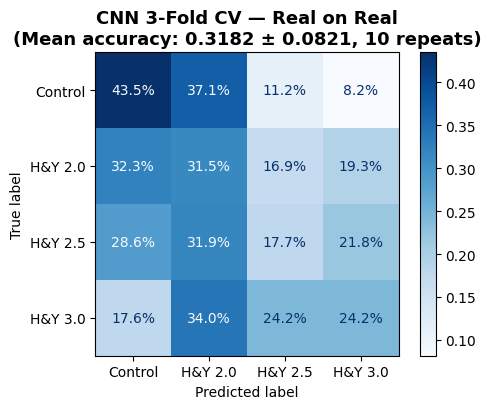


Class                 Precision             Recall                 F1
----------------------------------------------------------------------
Control          0.4218 ± 0.0355     0.4354 ± 0.0976     0.4238 ± 0.0631
H&Y 2.0          0.3412 ± 0.0411     0.3147 ± 0.1408     0.3160 ± 0.0826
H&Y 2.5          0.2492 ± 0.0542     0.1769 ± 0.0650     0.2040 ± 0.0595
H&Y 3.0          0.1333 ± 0.1069     0.2423 ± 0.1171     0.1589 ± 0.0884


In [8]:
# Confusion matrix + classification report (averaged across all repeats)

class_order = [HY_CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Accumulate confusion matrices across all repeats
cm_sum = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for preds in all_preds_repeats:
    cm_sum += confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))

# Row-normalise to percentages (each true-class row sums to 1.0)
cm_normalised = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True)

# Overall accuracy averaged across repeats
overall_acc = np.mean(repeat_fold_results)
overall_std = np.std(repeat_fold_results)

disp = ConfusionMatrixDisplay(cm_normalised, display_labels=class_order)

SCALE = 0.6

fig, ax = plt.subplots(figsize=(9*SCALE, 7*SCALE))
disp.plot(ax=ax, cmap='Blues', values_format='.1%')
ax.set_title(f'CNN {NUM_FOLDS}-Fold CV — Real on Real\n'
             f'(Mean accuracy: {overall_acc:.4f} ± {overall_std:.4f}, '
             f'{NUM_REPEATS} repeats)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix_real.png', dpi=1200, bbox_inches='tight')
plt.show()

# Per-class classification report averaged across repeats
# Compute precision/recall/F1 per repeat, then mean ± std
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s = [], [], []
for preds in all_preds_repeats:
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

precisions = np.array(precisions)  # shape (NUM_REPEATS, NUM_CLASSES)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

print(f"\n{'Class':<12s} {'Precision':>18s} {'Recall':>18s} {'F1':>18s}")
print("-" * 70)
for i, name in enumerate(class_order):
    print(f"{name:<12s} "
          f"{precisions[:, i].mean():>10.4f} ± {precisions[:, i].std():<5.4f} "
          f"{recalls[:, i].mean():>10.4f} ± {recalls[:, i].std():<5.4f} "
          f"{f1s[:, i].mean():>10.4f} ± {f1s[:, i].std():<5.4f}")

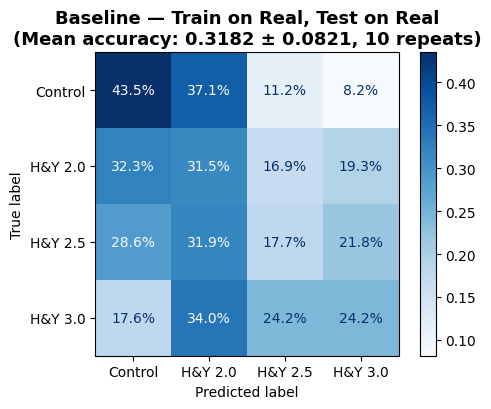


Class                 Precision             Recall                 F1
----------------------------------------------------------------------
Control          0.4218 ± 0.0355     0.4354 ± 0.0976     0.4238 ± 0.0631
H&Y 2.0          0.3412 ± 0.0411     0.3147 ± 0.1408     0.3160 ± 0.0826
H&Y 2.5          0.2492 ± 0.0542     0.1769 ± 0.0650     0.2040 ± 0.0595
H&Y 3.0          0.1333 ± 0.1069     0.2423 ± 0.1171     0.1589 ± 0.0884


In [22]:
# Confusion matrix + classification report (averaged across all repeats)

class_order = [HY_CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Accumulate confusion matrices across all repeats
cm_sum = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for preds in all_preds_repeats:
    cm_sum += confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))

# Row-normalise to percentages (each true-class row sums to 1.0)
cm_normalised = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True)

# Overall accuracy averaged across repeats
overall_acc = np.mean(repeat_fold_results)
overall_std = np.std(repeat_fold_results)

disp = ConfusionMatrixDisplay(cm_normalised, display_labels=class_order)

SCALE = 0.6

fig, ax = plt.subplots(figsize=(9*SCALE, 7*SCALE))
disp.plot(ax=ax, cmap='Blues', values_format='.1%')
ax.set_title(f'Baseline — Train on Real, Test on Real\n'
             f'(Mean accuracy: {overall_acc:.4f} ± {overall_std:.4f}, '
             f'{NUM_REPEATS} repeats)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix_real_sect4.png', dpi=1200, bbox_inches='tight')
plt.show()

# Per-class classification report averaged across repeats
# Compute precision/recall/F1 per repeat, then mean ± std
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s = [], [], []
for preds in all_preds_repeats:
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

precisions = np.array(precisions)  # shape (NUM_REPEATS, NUM_CLASSES)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

print(f"\n{'Class':<12s} {'Precision':>18s} {'Recall':>18s} {'F1':>18s}")
print("-" * 70)
for i, name in enumerate(class_order):
    print(f"{name:<12s} "
          f"{precisions[:, i].mean():>10.4f} ± {precisions[:, i].std():<5.4f} "
          f"{recalls[:, i].mean():>10.4f} ± {recalls[:, i].std():<5.4f} "
          f"{f1s[:, i].mean():>10.4f} ± {f1s[:, i].std():<5.4f}")

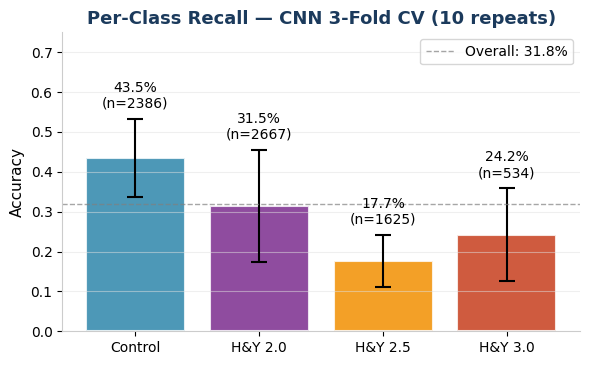


Class               Accuracy        Std
----------------------------------------
Control          0.4354 ± 0.0976
H&Y 2.0          0.3147 ± 0.1408
H&Y 2.5          0.1769 ± 0.0650
H&Y 3.0          0.2423 ± 0.1171


In [9]:
# Per-class accuracy bar chart (averaged across repeats with std error bars)

BG_COLOUR = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'
HY_COLOURS_LIST = ['#2E86AB', '#7B2D8E', '#F18F01', '#C73E1D']

# Compute per-class accuracy for each repeat
per_class_accs = []  # shape will be (NUM_REPEATS, NUM_CLASSES)
for preds in all_preds_repeats:
    cm_r = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    per_class_accs.append(cm_r.diagonal() / cm_r.sum(axis=1))

per_class_accs = np.array(per_class_accs)
per_class_mean = per_class_accs.mean(axis=0)
per_class_std  = per_class_accs.std(axis=0)

# Window counts per class (same across repeats)
class_counts_total = np.bincount(labels, minlength=NUM_CLASSES)

SCALE = 0.75

fig, ax = plt.subplots(figsize=(8*SCALE, 5*SCALE))
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

bars = ax.bar(class_order, per_class_mean, color=HY_COLOURS_LIST, alpha=0.85,
              edgecolor='white', linewidth=1.5,
              yerr=per_class_std, capsize=6,
              error_kw={'ecolor': 'black', 'capthick': 1.5, 'linewidth': 1.5})

for bar, acc, std, count in zip(bars, per_class_mean, per_class_std, class_counts_total):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.02,
            f'{acc:.1%}\n(n={count})',
            ha='center', va='bottom', fontsize=10)

overall_acc = np.mean(repeat_fold_results)

ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title(f'Per-Class Recall — CNN {NUM_FOLDS}-Fold CV '
             f'({NUM_REPEATS} repeats)',
             fontsize=13, fontweight='bold', color='#1B3A5C')
ax.set_ylim(0, 0.75)
ax.axhline(y=overall_acc, color='grey', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Overall: {overall_acc:.1%}')
ax.legend(fontsize=10)
ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('cnn_per_class_recall.png', dpi=900, bbox_inches='tight', facecolor=BG_COLOUR)
plt.show()

# Print numerical summary
print(f"\n{'Class':<12s} {'Accuracy':>15s} {'Std':>10s}")
print("-" * 40)
for name, acc, std in zip(class_order, per_class_mean, per_class_std):
    print(f"{name:<12s} {acc:>10.4f} ± {std:<5.4f}")

In [10]:
# Load generated signals from cGAN_H&Y
gen_data = np.load('C:/Users/simon/PycharmProjects/ParkinsonsDetection/W7 - H&Y cGAN/saved_models/generated_signals_hy_ver_0419_4Channel.npz')
valid_r = gen_data['valid_r']
valid_l = gen_data['valid_l']
valid_labels = gen_data['valid_labels']
valid_weights_kg = gen_data['valid_weights_kg']

# Stack into (N, 2, 1201) to match real_filtered format
gen_filtered = np.stack([valid_r, valid_l], axis=1).astype(np.float32)

print(f"Loaded {len(gen_filtered)} generated signals")
for cls_idx, cls_name in HY_CLASS_NAMES.items():
    print(f"  {cls_name}: {(valid_labels == cls_idx).sum()}")

Loaded 49152 generated signals
  Control: 11653
  H&Y 2.0: 11980
  H&Y 2.5: 11935
  H&Y 3.0: 13584


## TSTR — Train on Synthetic, Test on Real

The CNN is trained exclusively on cGAN-generated signals and tested on all
real signals. Since the generator never saw real subjects, there is no
subject leakage by construction. This is the purest test of whether the
synthetic data captures generalisable gait patterns.

In [11]:
# ========== CELL H (code) ==========
# TSTR — Train on generated, test on real (repeated for stable results)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def normalise_channels(train_data, test_data):
    mean = train_data.mean(axis=(0, 2), keepdims=True)
    std  = train_data.std(axis=(0, 2), keepdims=True) + 1e-8
    return (train_data - mean) / std, (test_data - mean) / std

X_train_tstr, X_test_tstr = normalise_channels(gen_filtered, real_filtered)
y_train_tstr = valid_labels.astype(np.int64)
y_test_tstr  = labels.astype(np.int64)

# Class weights from generated data
class_counts_gen = np.bincount(y_train_tstr, minlength=NUM_CLASSES)
cw_gen = 1.0 / class_counts_gen
cw_gen = cw_gen / cw_gen.sum() * NUM_CLASSES
cw_gen_tensor = torch.tensor(cw_gen, dtype=torch.float32).to(device)

print(f"Train (generated): {X_train_tstr.shape}")
print(f"Test  (real):      {X_test_tstr.shape}")

# Test dataloader (same across all repeats)
test_ds = TensorDataset(torch.tensor(X_test_tstr), torch.tensor(y_test_tstr, dtype=torch.long))
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

NUM_REPEATS = 10

tstr_repeat_accuracies = []
tstr_preds_repeats = []
tstr_probs_repeats = []

for repeat in range(NUM_REPEATS):
    print(f"\n{'#'*60}")
    print(f"# TSTR REPEAT {repeat + 1}/{NUM_REPEATS}")
    print(f"{'#'*60}")

    # Different seed each repeat — changes both the early-stopping split and weight init
    torch.manual_seed(repeat)
    np.random.seed(repeat)

    # Held-out portion of generated data for early stopping (varies each repeat)
    n_gen = len(X_train_tstr)
    gen_perm = np.random.RandomState(repeat).permutation(n_gen)
    n_val_gen = int(0.15 * n_gen)
    gen_train_idx = gen_perm[n_val_gen:]
    gen_val_idx   = gen_perm[:n_val_gen]

    gen_train_ds = TensorDataset(torch.tensor(X_train_tstr[gen_train_idx]),
                                  torch.tensor(y_train_tstr[gen_train_idx], dtype=torch.long))
    gen_val_ds   = TensorDataset(torch.tensor(X_train_tstr[gen_val_idx]),
                                  torch.tensor(y_train_tstr[gen_val_idx], dtype=torch.long))
    gen_train_dl = DataLoader(gen_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    gen_val_dl   = DataLoader(gen_val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    # Fresh model each repeat
    model_tstr = GaitCNN(
        num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, dropout=DROPOUT
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=cw_gen_tensor)
    optimizer = optim.Adam(model_tstr.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=7, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(NUM_EPOCHS):
        if epoch % 5 == 0:
            print(f"  Epoch: {epoch}/{NUM_EPOCHS}")

        model_tstr.train()
        for X_batch, y_batch in gen_train_dl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model_tstr(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model_tstr.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in gen_val_dl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model_tstr(X_batch), y_batch).item() * len(y_batch)
        val_loss /= len(gen_val_idx)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model_tstr.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    # Evaluate on all real data
    model_tstr.load_state_dict(best_model_state)
    model_tstr.eval()

    preds = []
    probs = []
    with torch.no_grad():
        for X_batch, y_batch in test_dl:
            X_batch = X_batch.to(device)
            logits = model_tstr(X_batch)
            preds.append(logits.argmax(1).cpu().numpy())
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())

    preds = np.concatenate(preds)
    probs = np.concatenate(probs)
    acc = (preds == y_test_tstr).mean()

    tstr_repeat_accuracies.append(acc)
    tstr_preds_repeats.append(preds)
    tstr_probs_repeats.append(probs)

    print(f"  Repeat {repeat + 1} accuracy: {acc:.4f}")

# Summary
tstr_accuracy = np.mean(tstr_repeat_accuracies)
tstr_accuracy_std = np.std(tstr_repeat_accuracies)

print(f"\n{'='*60}")
print(f"TSTR accuracy across {NUM_REPEATS} repeats: "
      f"{tstr_accuracy:.4f} (+/- {tstr_accuracy_std:.4f})")
print(f"Per-repeat: {[f'{a:.4f}' for a in tstr_repeat_accuracies]}")

# Keep compatible with downstream cells
tstr_preds = tstr_preds_repeats[0]
tstr_probs = tstr_probs_repeats[0]

Train (generated): (49152, 2, 1201)
Test  (real):      (7212, 2, 1201)

############################################################
# TSTR REPEAT 1/10
############################################################
  Epoch: 0/300
  Epoch: 5/300
  Epoch: 10/300
  Epoch: 15/300
  Epoch: 20/300
  Epoch: 25/300
  Epoch: 30/300
  Epoch: 35/300
  Epoch: 40/300
  Epoch: 45/300
  Epoch: 50/300
  Epoch: 55/300
  Epoch: 60/300
  Epoch: 65/300
  Epoch: 70/300
  Epoch: 75/300
  Epoch: 80/300
  Epoch: 85/300
  Epoch: 90/300
  Early stopping at epoch 93
  Repeat 1 accuracy: 0.7709

############################################################
# TSTR REPEAT 2/10
############################################################
  Epoch: 0/300
  Epoch: 5/300
  Epoch: 10/300
  Epoch: 15/300
  Epoch: 20/300
  Epoch: 25/300
  Epoch: 30/300
  Epoch: 35/300
  Epoch: 40/300
  Epoch: 45/300
  Epoch: 50/300
  Epoch: 55/300
  Epoch: 60/300
  Epoch: 65/300
  Epoch: 70/300
  Epoch: 75/300
  Epoch: 80/300
  Epoch: 85/300


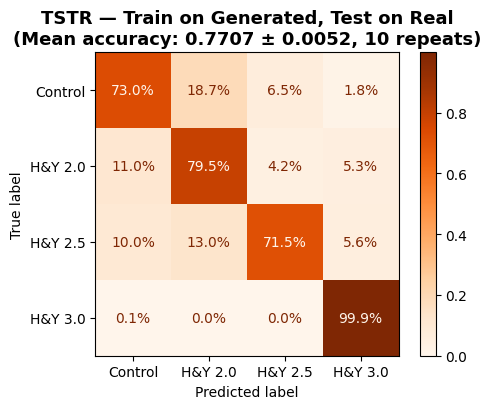


Class                 Precision             Recall                 F1
----------------------------------------------------------------------
Control          0.7934 ± 0.0191     0.7301 ± 0.0239     0.7600 ± 0.0112
H&Y 2.0          0.7640 ± 0.0185     0.7951 ± 0.0155     0.7789 ± 0.0061
H&Y 2.5          0.8143 ± 0.0140     0.7153 ± 0.0124     0.7614 ± 0.0064
H&Y 3.0          0.6620 ± 0.0304     0.9993 ± 0.0015     0.7959 ± 0.0216


In [12]:
# ========== CELL I (code) ==========
# TSTR confusion matrix + classification report (averaged across all repeats)

class_order = [HY_CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Accumulate confusion matrices across all TSTR repeats
cm_sum_tstr = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for preds in tstr_preds_repeats:
    cm_sum_tstr += confusion_matrix(y_test_tstr, preds, labels=list(range(NUM_CLASSES)))

# Row-normalise to percentages (each true-class row sums to 1.0)
cm_tstr_normalised = cm_sum_tstr.astype(float) / cm_sum_tstr.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(cm_tstr_normalised, display_labels=class_order)

SCALE = 0.6

fig, ax = plt.subplots(figsize=(9*SCALE, 7*SCALE))
disp.plot(ax=ax, cmap='Oranges', values_format='.1%')
ax.set_title(f'TSTR — Train on Generated, Test on Real\n'
             f'(Mean accuracy: {tstr_accuracy:.4f} ± {tstr_accuracy_std:.4f}, '
             f'{len(tstr_preds_repeats)} repeats)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix_tstrC.png', dpi=1200, bbox_inches='tight')
plt.show()

# Per-class precision/recall/F1 averaged across repeats
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s = [], [], []
for preds in tstr_preds_repeats:
    p, r, f, _ = precision_recall_fscore_support(
        y_test_tstr, preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

print(f"\n{'Class':<12s} {'Precision':>18s} {'Recall':>18s} {'F1':>18s}")
print("-" * 70)
for i, name in enumerate(class_order):
    print(f"{name:<12s} "
          f"{precisions[:, i].mean():>10.4f} ± {precisions[:, i].std():<5.4f} "
          f"{recalls[:, i].mean():>10.4f} ± {recalls[:, i].std():<5.4f} "
          f"{f1s[:, i].mean():>10.4f} ± {f1s[:, i].std():<5.4f}")

## Augmented — Real + Generated Training Data

The same subject-level GroupKFold setup as the baseline, but each training
fold is augmented with all generated signals. The validation fold remains
real-only and subject-disjoint, so the evaluation is directly comparable
to the real-only baseline.

In [13]:

# ========== CELL K (code) ==========
# Augmented training: Real + Generated (repeated subject-level GroupKFold)
from sklearn.model_selection import GroupKFold

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Class weights computed on combined real + generated
combined_counts = np.bincount(labels, minlength=NUM_CLASSES) + \
                  np.bincount(valid_labels.astype(np.int64), minlength=NUM_CLASSES)
cw_aug = 1.0 / combined_counts
cw_aug = cw_aug / cw_aug.sum() * NUM_CLASSES
cw_aug_tensor = torch.tensor(cw_aug, dtype=torch.float32).to(device)

NUM_REPEATS = 10

aug_repeat_fold_results = []   # flat list of all fold accuracies
aug_all_preds_repeats = []     # list of (N,) arrays, one per repeat
aug_all_probs_repeats = []     # list of (N, NUM_CLASSES) arrays, one per repeat

print(f"Real data: {len(real_filtered)}, Generated data: {len(gen_filtered)}")
print(f"Splitting real data by {len(np.unique(subject_ids))} subjects "
      f"across {NUM_FOLDS} folds × {NUM_REPEATS} repeats\n")

for repeat in range(NUM_REPEATS):
    print(f"\n{'#'*60}")
    print(f"# REPEAT {repeat + 1}/{NUM_REPEATS}")
    print(f"{'#'*60}")

    # Shuffle subject-level group assignments so folds change each repeat
    gkf = GroupKFold(n_splits=NUM_FOLDS)
    rng = np.random.RandomState(repeat)
    unique_subs = np.unique(subject_ids)
    permuted = rng.permutation(unique_subs)
    sub_map = dict(zip(unique_subs, permuted))
    shuffled_groups = np.array([sub_map[s] for s in subject_ids])

    aug_all_preds = np.zeros(len(labels), dtype=np.int64)
    aug_all_probs = np.zeros((len(labels), NUM_CLASSES), dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(gkf.split(real_filtered, labels, groups=shuffled_groups)):

        train_subjects = np.unique(subject_ids[train_idx])
        val_subjects   = np.unique(subject_ids[val_idx])

        X_train_real = real_filtered[train_idx]
        y_train_real = labels[train_idx]

        X_val = real_filtered[val_idx]
        y_val = labels[val_idx]

        # Augment training with ALL generated data
        X_train_aug = np.concatenate([X_train_real, gen_filtered], axis=0)
        y_train_aug = np.concatenate([y_train_real, valid_labels.astype(np.int64)], axis=0)

        # Normalise (fit on augmented training set)
        X_train_aug, X_val = normalise_channels(X_train_aug, X_val)

        print(f"{'='*50}")
        print(f"Repeat {repeat + 1} Fold {fold + 1}/{NUM_FOLDS}")
        print(f"  Train: {len(X_train_real)} real + {len(gen_filtered)} gen = {len(X_train_aug)} total")
        print(f"  Val:   {len(X_val)} real ({len(val_subjects)} subjects)")

        # Dataloaders
        train_ds = TensorDataset(torch.tensor(X_train_aug), torch.tensor(y_train_aug, dtype=torch.long))
        val_ds   = TensorDataset(torch.tensor(X_val),       torch.tensor(y_val, dtype=torch.long))
        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        # Fresh model (also re-seeded per fold-repeat)
        torch.manual_seed(repeat * 100 + fold)
        model = GaitCNN(
            num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, dropout=DROPOUT
        ).to(device)

        criterion = nn.CrossEntropyLoss(weight=cw_aug_tensor)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=7, factor=0.5)

        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0

        for epoch in range(NUM_EPOCHS):
            if epoch % 5 == 0:
                print(f"  Epoch {epoch}/{NUM_EPOCHS}")

            model.train()
            train_loss = 0
            for X_batch, y_batch in train_dl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * len(y_batch)
            train_loss /= len(X_train_aug)

            model.eval()
            val_loss = 0
            correct = 0
            with torch.no_grad():
                for X_batch, y_batch in val_dl:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    logits = model(X_batch)
                    loss = criterion(logits, y_batch)
                    val_loss += loss.item() * len(y_batch)
                    correct += (logits.argmax(1) == y_batch).sum().item()
            val_loss /= len(val_idx)

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

        model.load_state_dict(best_model_state)
        model.eval()

        val_preds = []
        val_probs = []
        with torch.no_grad():
            for X_batch, y_batch in val_dl:
                X_batch = X_batch.to(device)
                logits = model(X_batch)
                probs = torch.softmax(logits, dim=1)
                val_preds.append(logits.argmax(1).cpu().numpy())
                val_probs.append(probs.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_probs = np.concatenate(val_probs)
        fold_acc = (val_preds == y_val).mean()

        aug_all_preds[val_idx] = val_preds
        aug_all_probs[val_idx] = val_probs
        aug_repeat_fold_results.append(fold_acc)

        print(f"  Val accuracy: {fold_acc:.4f}  (best val loss: {best_val_loss:.4f})")

    aug_all_preds_repeats.append(aug_all_preds)
    aug_all_probs_repeats.append(aug_all_probs)

# Summary
aug_mean = np.mean(aug_repeat_fold_results)
aug_std = np.std(aug_repeat_fold_results)

print(f"\n{'='*60}")
print(f"Augmented accuracy across {NUM_REPEATS} repeats × {NUM_FOLDS} folds: "
      f"{aug_mean:.4f} (+/- {aug_std:.4f})")
print(f"n = {len(aug_repeat_fold_results)} total fold evaluations")

# Keep compatible with downstream cells
aug_all_preds = aug_all_preds_repeats[0]
aug_all_probs = aug_all_probs_repeats[0]

Real data: 7212, Generated data: 49152
Splitting real data by 162 subjects across 3 folds × 10 repeats


############################################################
# REPEAT 1/10
############################################################
Repeat 1 Fold 1/3
  Train: 4806 real + 49152 gen = 53958 total
  Val:   2406 real (54 subjects)
  Epoch 0/300
  Epoch 5/300
  Epoch 10/300
  Epoch 15/300
  Epoch 20/300
  Epoch 25/300
  Early stopping at epoch 26
  Val accuracy: 0.7793  (best val loss: 0.7401)
Repeat 1 Fold 2/3
  Train: 4808 real + 49152 gen = 53960 total
  Val:   2404 real (54 subjects)
  Epoch 0/300
  Epoch 5/300
  Epoch 10/300
  Epoch 15/300
  Epoch 20/300
  Early stopping at epoch 21
  Val accuracy: 0.6905  (best val loss: 0.8968)
Repeat 1 Fold 3/3
  Train: 4810 real + 49152 gen = 53962 total
  Val:   2402 real (54 subjects)
  Epoch 0/300
  Epoch 5/300
  Epoch 10/300
  Epoch 15/300
  Epoch 20/300
  Epoch 25/300
  Early stopping at epoch 26
  Val accuracy: 0.8201  (best val loss:

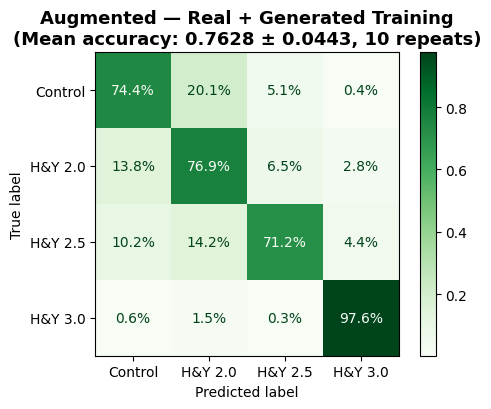


Class                 Precision             Recall                 F1
----------------------------------------------------------------------
Control          0.7748 ± 0.0516     0.7436 ± 0.0610     0.7548 ± 0.0184
H&Y 2.0          0.7431 ± 0.0339     0.7685 ± 0.0406     0.7540 ± 0.0143
H&Y 2.5          0.7996 ± 0.0469     0.7116 ± 0.0296     0.7515 ± 0.0165
H&Y 3.0          0.7701 ± 0.0346     0.9758 ± 0.0194     0.8604 ± 0.0238


In [14]:
# ========== CELL L (code) ==========
# Augmented confusion matrix + classification report (averaged across all repeats)

class_order = [HY_CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Accumulate confusion matrices across all augmented repeats
cm_sum_aug = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for preds in aug_all_preds_repeats:
    cm_sum_aug += confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))

# Row-normalise to percentages (each true-class row sums to 1.0)
cm_aug_normalised = cm_sum_aug.astype(float) / cm_sum_aug.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(cm_aug_normalised, display_labels=class_order)

SCALE = 0.6

fig, ax = plt.subplots(figsize=(9*SCALE, 7*SCALE))
disp.plot(ax=ax, cmap='Greens', values_format='.1%')
ax.set_title(f'Augmented — Real + Generated Training\n'
             f'(Mean accuracy: {aug_mean:.4f} ± {aug_std:.4f}, '
             f'{len(aug_all_preds_repeats)} repeats)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix_augmentedC.png', dpi=1200, bbox_inches='tight')
plt.show()

# Per-class precision/recall/F1 averaged across repeats
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s = [], [], []
for preds in aug_all_preds_repeats:
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

print(f"\n{'Class':<12s} {'Precision':>18s} {'Recall':>18s} {'F1':>18s}")
print("-" * 70)
for i, name in enumerate(class_order):
    print(f"{name:<12s} "
          f"{precisions[:, i].mean():>10.4f} ± {precisions[:, i].std():<5.4f} "
          f"{recalls[:, i].mean():>10.4f} ± {recalls[:, i].std():<5.4f} "
          f"{f1s[:, i].mean():>10.4f} ± {f1s[:, i].std():<5.4f}")

## Summary Comparison

In [15]:
# # ========== CELL N (code) ==========
# # Summary comparison table + bar chart
#
# BG_COLOUR = '#FFFFFF'
# GRID_COLOUR = '#E0E0E0'
#
# # Collect results
# baseline_acc = np.mean(repeat_fold_results)        # from Cell D
# baseline_std = np.std(repeat_fold_results)
# tstr_acc_val = tstr_accuracy                # from Cell H (single number, no CV)
# aug_acc = np.mean(aug_fold_results)          # from Cell K
# aug_std = np.std(aug_fold_results)
#
# print("=" * 60)
# print(f"{'Condition':<30s} {'Accuracy':>10s} {'Std':>10s}")
# print("-" * 60)
# print(f"{'Real only (baseline)':<30s} {baseline_acc:>10.4f} {baseline_std:>10.4f}")
# print(f"{'TSTR (generated only)':<30s} {tstr_acc_val:>10.4f} {'—':>10s}")
# print(f"{'Real + Generated':<30s} {aug_acc:>10.4f} {aug_std:>10.4f}")
# print("=" * 60)
#
# # Bar chart
# conditions = ['Real Only\n(Baseline)', 'TSTR\n(Gen Only)', 'Real +\nGenerated']
# accuracies = [baseline_acc, tstr_acc_val, aug_acc]
# colours = ['#2E86AB', '#F18F01', '#2ECC71']
#
# fig, ax = plt.subplots(figsize=(8, 5))
# fig.patch.set_facecolor(BG_COLOUR)
# ax.set_facecolor(BG_COLOUR)
#
# bars = ax.bar(conditions, accuracies, color=colours, alpha=0.85,
#               edgecolor='white', linewidth=2, width=0.5)
#
# # Error bars for CV conditions
# ax.errorbar([0], [baseline_acc], yerr=[baseline_std], fmt='none',
#             ecolor='black', capsize=8, capthick=1.5, linewidth=1.5)
# ax.errorbar([2], [aug_acc], yerr=[aug_std], fmt='none',
#             ecolor='black', capsize=8, capthick=1.5, linewidth=1.5)
#
# for bar, acc in zip(bars, accuracies):
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
#             f'{acc:.1%}', ha='center', va='bottom', fontsize=13, fontweight='bold')
#
# ax.axhline(y=0.25, color='grey', linestyle=':', linewidth=1, alpha=0.7,
#            label='Random chance (25%)')
# ax.set_ylabel('Accuracy', fontsize=12)
# ax.set_title('CNN Classification Accuracy — 4-Class H&Y Staging\n(Subject-Level Splits)',
#              fontsize=14, fontweight='bold', color='#1B3A5C')
# ax.set_ylim(0, max(accuracies) + 0.12)
# ax.legend(fontsize=10, loc='upper right')
# ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.8, alpha=0.5)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('#CCCCCC')
# ax.spines['bottom'].set_color('#CCCCCC')
#
# plt.tight_layout()
# plt.savefig('cnn_comparison_summaryC.png', dpi=600, bbox_inches='tight', facecolor=BG_COLOUR)
# plt.show()

In [16]:
# ========== CELL O (markdown) ==========
# ## Classical Augmentation Baseline
#
# A fourth condition where the CNN is trained on real data augmented with
# standard signal processing techniques (jittering, scaling, time warping,
# magnitude warping, window shifting). This provides a comparison point that
# isolates the contribution of the cGAN against generic augmentation methods.


# ========== CELL P (code) ==========
# Classical augmentation transforms

from scipy.interpolate import CubicSpline

class GaitAugment:
    """Amplitude and temporal scaling about the origin.

    Preserves the gait cycle phase alignment (right stance starts at sample 0)
    while introducing realistic subject-level variation.
    """
    def __init__(self, scale_range=(0.85, 1.15), time_scale_range=(0.9, 1.1), p=0.5):
        self.scale_range = scale_range
        self.time_scale_range = time_scale_range
        self.p = p

    def time_scale(self, x):
        """Rescale signal duration about the origin, then pad/crop to original length."""
        length = x.shape[1]
        factor = np.random.uniform(*self.time_scale_range)
        new_length = int(round(length * factor))

        # Resample each channel
        rescaled = np.zeros((x.shape[0], new_length))
        for c in range(x.shape[0]):
            rescaled[c] = np.interp(
                np.linspace(0, length - 1, new_length),
                np.arange(length),
                x[c]
            )

        # Fit back to original length, anchored at origin
        out = np.zeros_like(x)
        if new_length >= length:
            out = rescaled[:, :length]
        else:
            out[:, :new_length] = rescaled
            # Leave the tail as zeros (stance-off at end — plausible)
        return out

    def __call__(self, x):
        x = x.copy()
        if np.random.rand() < self.p:
            x = self.time_scale(x)
        return x.astype(np.float32)


class AugmentedDataset(torch.utils.data.Dataset):
    """Dataset wrapper that applies augmentation on-the-fly during training."""
    def __init__(self, X, y, augment=None):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment is not None:
            x = self.augment(x)
        return torch.tensor(x), torch.tensor(self.y[idx], dtype=torch.long)


# Quick visual check — plot an augmented vs original signal
augmenter = GaitAugment()
sample_idx = np.random.randint(len(real_filtered))
original = real_filtered[sample_idx]
augmented_examples = [augmenter(original) for _ in range(3)]

# fig, axes = plt.subplots(2, 4, figsize=(16, 6))
# for col, (sig, title) in enumerate(zip(
#     [original] + augmented_examples,
#     ['Original', 'Aug 1', 'Aug 2', 'Aug 3']
# )):
#     axes[0, col].plot(sig[0], color='#2E86AB', linewidth=1)
#     axes[0, col].set_title(f'{title} — Right foot')
#     axes[0, col].set_ylim(bottom=0)
#     axes[1, col].plot(sig[1], color='#C73E1D', linewidth=1)
#     axes[1, col].set_title(f'{title} — Left foot')
#     axes[1, col].set_ylim(bottom=0)
# plt.tight_layout()
# plt.savefig('classical_augmentation_examples.png', dpi=600, bbox_inches='tight')
# plt.show()


In [17]:
# ========== CELL Q (code) ==========
# Classical augmentation training (repeated subject-level GroupKFold)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Use the same class weights as the real-only baseline
class_counts_real = np.bincount(labels, minlength=NUM_CLASSES)
cw_real = 1.0 / class_counts_real
cw_real = cw_real / cw_real.sum() * NUM_CLASSES
cw_real_tensor = torch.tensor(cw_real, dtype=torch.float32).to(device)

NUM_REPEATS = 10
augmenter = GaitAugment()

classic_repeat_fold_results = []
classic_all_preds_repeats = []
classic_all_probs_repeats = []

print(f"Real data: {len(real_filtered)}")
print(f"Classical augmentation on-the-fly during training")
print(f"Splitting by {len(np.unique(subject_ids))} subjects "
      f"across {NUM_FOLDS} folds × {NUM_REPEATS} repeats\n")

for repeat in range(NUM_REPEATS):
    print(f"\n{'#'*60}")
    print(f"# REPEAT {repeat + 1}/{NUM_REPEATS}")
    print(f"{'#'*60}")

    # Shuffle subject-level group assignments each repeat
    gkf = GroupKFold(n_splits=NUM_FOLDS)
    rng = np.random.RandomState(repeat)
    unique_subs = np.unique(subject_ids)
    permuted = rng.permutation(unique_subs)
    sub_map = dict(zip(unique_subs, permuted))
    shuffled_groups = np.array([sub_map[s] for s in subject_ids])

    classic_all_preds = np.zeros(len(labels), dtype=np.int64)
    classic_all_probs = np.zeros((len(labels), NUM_CLASSES), dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(gkf.split(real_filtered, labels, groups=shuffled_groups)):

        val_subjects = np.unique(subject_ids[val_idx])

        X_train = real_filtered[train_idx]
        y_train = labels[train_idx]
        X_val = real_filtered[val_idx]
        y_val = labels[val_idx]

        # Normalise (fit on train only)
        X_train, X_val = normalise_channels(X_train, X_val)

        # Training dataloader uses augmentation; validation does not
        # Include both original and augmented versions
        train_ds_original = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
        train_ds_augmented_copies = [
            AugmentedDataset(X_train, y_train, augment=augmenter)
            for _ in range(1)
        ]
        train_ds = torch.utils.data.ConcatDataset([train_ds_original] + train_ds_augmented_copies)
        val_ds   = TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long))
        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        print(f"{'='*50}")
        print(f"Repeat {repeat + 1} Fold {fold + 1}/{NUM_FOLDS}")
        print(f"  Train: {len(train_ds)} real + augmented")
        print(f"  Val:   {len(val_ds)} real ({len(val_subjects)} subjects)")

        # Fresh model
        torch.manual_seed(repeat * 100 + fold)
        model = GaitCNN(
            num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, dropout=DROPOUT
        ).to(device)

        criterion = nn.CrossEntropyLoss(weight=cw_real_tensor)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=7, factor=0.5)

        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0

        for epoch in range(NUM_EPOCHS):
            if epoch % 5 == 0:
                print(f"  Epoch {epoch}/{NUM_EPOCHS}")

            model.train()
            for X_batch, y_batch in train_dl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()

            model.eval()
            val_loss = 0
            correct = 0
            with torch.no_grad():
                for X_batch, y_batch in val_dl:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    logits = model(X_batch)
                    loss = criterion(logits, y_batch)
                    val_loss += loss.item() * len(y_batch)
                    correct += (logits.argmax(1) == y_batch).sum().item()
            val_loss /= len(val_idx)

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

        model.load_state_dict(best_model_state)
        model.eval()

        val_preds = []
        val_probs = []
        with torch.no_grad():
            for X_batch, y_batch in val_dl:
                X_batch = X_batch.to(device)
                logits = model(X_batch)
                probs = torch.softmax(logits, dim=1)
                val_preds.append(logits.argmax(1).cpu().numpy())
                val_probs.append(probs.cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_probs = np.concatenate(val_probs)
        fold_acc = (val_preds == y_val).mean()

        classic_all_preds[val_idx] = val_preds
        classic_all_probs[val_idx] = val_probs
        classic_repeat_fold_results.append(fold_acc)

        print(f"  Val accuracy: {fold_acc:.4f}  (best val loss: {best_val_loss:.4f})")

    classic_all_preds_repeats.append(classic_all_preds)
    classic_all_probs_repeats.append(classic_all_probs)

# Summary
classic_mean = np.mean(classic_repeat_fold_results)
classic_std = np.std(classic_repeat_fold_results)

print(f"\n{'='*60}")
print(f"Classical augmentation accuracy across {NUM_REPEATS} repeats × {NUM_FOLDS} folds: "
      f"{classic_mean:.4f} (+/- {classic_std:.4f})")

# Keep compatible with downstream cells
classic_all_preds = classic_all_preds_repeats[0]
classic_all_probs = classic_all_probs_repeats[0]

Real data: 7212
Classical augmentation on-the-fly during training
Splitting by 162 subjects across 3 folds × 10 repeats


############################################################
# REPEAT 1/10
############################################################
Repeat 1 Fold 1/3
  Train: 9612 real + augmented
  Val:   2406 real (54 subjects)
  Epoch 0/300
  Epoch 5/300
  Epoch 10/300
  Epoch 15/300
  Epoch 20/300
  Early stopping at epoch 21
  Val accuracy: 0.2523  (best val loss: 1.7083)
Repeat 1 Fold 2/3
  Train: 9616 real + augmented
  Val:   2404 real (54 subjects)
  Epoch 0/300
  Epoch 5/300
  Epoch 10/300
  Epoch 15/300
  Epoch 20/300
  Early stopping at epoch 21
  Val accuracy: 0.3074  (best val loss: 1.3937)
Repeat 1 Fold 3/3
  Train: 9620 real + augmented
  Val:   2402 real (54 subjects)
  Epoch 0/300
  Epoch 5/300
  Epoch 10/300
  Epoch 15/300
  Epoch 20/300
  Early stopping at epoch 21
  Val accuracy: 0.4430  (best val loss: 1.3715)

#############################################

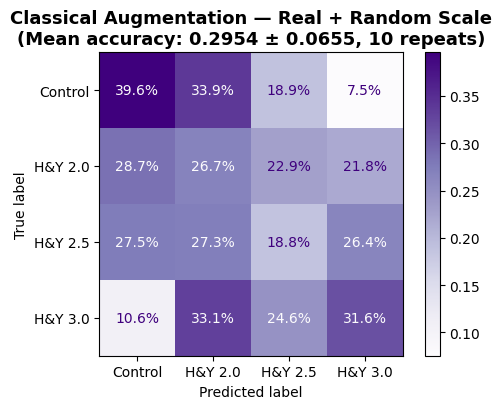


Class                 Precision             Recall                 F1
----------------------------------------------------------------------
Control          0.4331 ± 0.0642     0.3962 ± 0.0819     0.4083 ± 0.0527
H&Y 2.0          0.3380 ± 0.0604     0.2666 ± 0.0667     0.2937 ± 0.0562
H&Y 2.5          0.1971 ± 0.0405     0.1876 ± 0.0713     0.1885 ± 0.0596
H&Y 3.0          0.1215 ± 0.0578     0.3163 ± 0.1466     0.1733 ± 0.0812


In [23]:
# ========== CELL R (code) ==========
# Classical augmentation confusion matrix + classification report (averaged across all repeats)

class_order = [HY_CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Accumulate confusion matrices across all classical augmentation repeats
cm_sum_classic = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for preds in classic_all_preds_repeats:
    cm_sum_classic += confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))

# Row-normalise to percentages (each true-class row sums to 1.0)
cm_classic_normalised = cm_sum_classic.astype(float) / cm_sum_classic.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(cm_classic_normalised, display_labels=class_order)

SCALE = 0.6

fig, ax = plt.subplots(figsize=(9*SCALE, 7*SCALE))
disp.plot(ax=ax, cmap='Purples', values_format='.1%')
ax.set_title(f'Classical Augmentation — Real + Random Scale\n'
             f'(Mean accuracy: {classic_mean:.4f} ± {classic_std:.4f}, '
             f'{len(classic_all_preds_repeats)} repeats)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix_classicalB.png', dpi=1200, bbox_inches='tight')
plt.show()

# Per-class precision/recall/F1 averaged across repeats
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s = [], [], []
for preds in classic_all_preds_repeats:
    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)

print(f"\n{'Class':<12s} {'Precision':>18s} {'Recall':>18s} {'F1':>18s}")
print("-" * 70)
for i, name in enumerate(class_order):
    print(f"{name:<12s} "
          f"{precisions[:, i].mean():>10.4f} ± {precisions[:, i].std():<5.4f} "
          f"{recalls[:, i].mean():>10.4f} ± {recalls[:, i].std():<5.4f} "
          f"{f1s[:, i].mean():>10.4f} ± {f1s[:, i].std():<5.4f}")

Condition                               Accuracy          Std
----------------------------------------------------------------------
Real only (baseline)                      0.3182       0.0821
Real + Classical Augmentation             0.2954       0.0655
TSTR (generated only)                     0.7707       0.0052
Real + Generated (cGAN)                   0.7628       0.0443


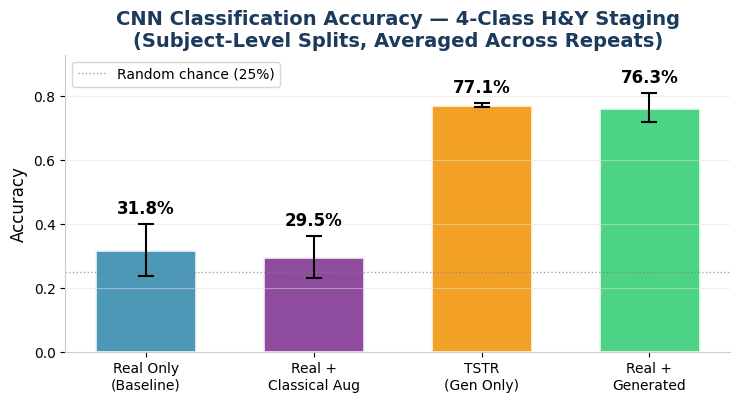

In [19]:
# ========== CELL S (code) ==========
# Final comparison — 4 conditions (averaged across all repeats)

BG_COLOUR = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'

baseline_acc = np.mean(repeat_fold_results)
baseline_std = np.std(repeat_fold_results)

print("=" * 70)
print(f"{'Condition':<35s} {'Accuracy':>12s} {'Std':>12s}")
print("-" * 70)
print(f"{'Real only (baseline)':<35s} {baseline_acc:>12.4f} {baseline_std:>12.4f}")
print(f"{'Real + Classical Augmentation':<35s} {classic_mean:>12.4f} {classic_std:>12.4f}")
print(f"{'TSTR (generated only)':<35s} {tstr_accuracy:>12.4f} {tstr_accuracy_std:>12.4f}")
print(f"{'Real + Generated (cGAN)':<35s} {aug_mean:>12.4f} {aug_std:>12.4f}")
print("=" * 70)

conditions = ['Real Only\n(Baseline)', 'Real +\nClassical Aug', 'TSTR\n(Gen Only)', 'Real +\nGenerated']
accuracies = [baseline_acc, classic_mean, tstr_accuracy, aug_mean]
errors     = [baseline_std, classic_std, tstr_accuracy_std, aug_std]
colours    = ['#2E86AB', '#7B2D8E', '#F18F01', '#2ECC71']

SCALE = 0.75

fig, ax = plt.subplots(figsize=(10*SCALE, 5.5*SCALE))
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

bars = ax.bar(conditions, accuracies, color=colours, alpha=0.85,
              edgecolor='white', linewidth=2, width=0.6,
              yerr=errors, capsize=6,
              error_kw={'ecolor': 'black', 'capthick': 1.5, 'linewidth': 1.5})

for bar, acc, err in zip(bars, accuracies, errors):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + err + 0.02,
            f'{acc:.1%}',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.axhline(y=0.25, color='grey', linestyle=':', linewidth=1, alpha=0.7,
           label='Random chance (25%)')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('CNN Classification Accuracy — 4-Class H&Y Staging\n'
             '(Subject-Level Splits, Averaged Across Repeats)',
             fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_ylim(0, max(a + e for a, e in zip(accuracies, errors)) + 0.12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('cnn_comparison_summary_full.png', dpi=600, bbox_inches='tight', facecolor=BG_COLOUR)
plt.show()

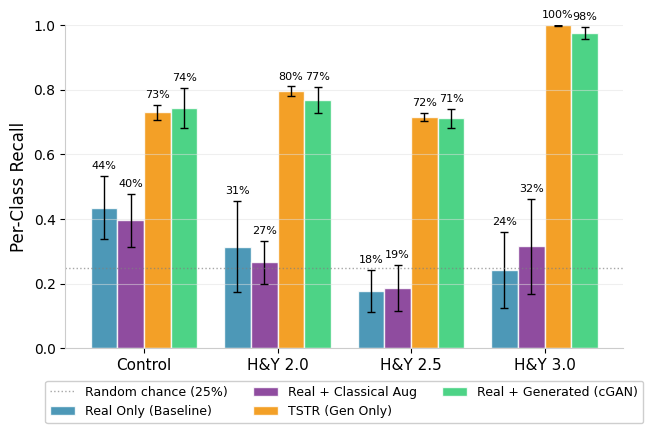


Class        Real Only (Baseline)      Real + Classical Aug      TSTR (Gen Only)           Real + Generated (cGAN)  
--------------------------------------------------------------------------------------------------------------------
Control      0.435 ± 0.098          0.396 ± 0.082          0.730 ± 0.024          0.744 ± 0.061          
H&Y 2.0      0.315 ± 0.141          0.267 ± 0.067          0.795 ± 0.015          0.769 ± 0.041          
H&Y 2.5      0.177 ± 0.065          0.188 ± 0.071          0.715 ± 0.012          0.712 ± 0.030          
H&Y 3.0      0.242 ± 0.117          0.316 ± 0.147          0.999 ± 0.001          0.976 ± 0.019          


In [24]:
# ========== CELL T (code) ==========
# Grouped per-class accuracy — all 4 conditions averaged across repeats

BG_COLOUR = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'

# Compute per-class accuracy (mean ± std across repeats) for each condition
def per_class_stats(preds_repeats, ground_truth):
    """Returns (mean, std) arrays of shape (NUM_CLASSES,)."""
    per_repeat = []
    for preds in preds_repeats:
        cm_r = confusion_matrix(ground_truth, preds, labels=list(range(NUM_CLASSES)))
        per_repeat.append(cm_r.diagonal() / cm_r.sum(axis=1))
    per_repeat = np.array(per_repeat)
    return per_repeat.mean(axis=0), per_repeat.std(axis=0)

baseline_mean, baseline_std_pc = per_class_stats(all_preds_repeats,     labels)
classic_mean_pc, classic_std_pc = per_class_stats(classic_all_preds_repeats, labels)
tstr_mean_pc,    tstr_std_pc    = per_class_stats(tstr_preds_repeats,   y_test_tstr)
aug_mean_pc,     aug_std_pc     = per_class_stats(aug_all_preds_repeats, labels)

class_order = [HY_CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Stack into (NUM_CONDITIONS, NUM_CLASSES)
condition_names = ['Real Only (Baseline)', 'Real + Classical Aug',
                   'TSTR (Gen Only)', 'Real + Generated (cGAN)']
means = np.array([baseline_mean, classic_mean_pc, tstr_mean_pc, aug_mean_pc])
stds  = np.array([baseline_std_pc, classic_std_pc, tstr_std_pc, aug_std_pc])
colours = ['#2E86AB', '#7B2D8E', '#F18F01', '#2ECC71']

# Plot setup
SCALE = 0.6

fig, ax = plt.subplots(figsize=(12*SCALE, 7*SCALE))
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

n_conditions = len(condition_names)
n_classes = NUM_CLASSES
bar_width = 0.2
x = np.arange(n_classes)

for i, (name, colour) in enumerate(zip(condition_names, colours)):
    offset = (i - (n_conditions - 1) / 2) * bar_width
    bars = ax.bar(x + offset, means[i], bar_width,
                  label=name, color=colour, alpha=0.85,
                  edgecolor='white', linewidth=1,
                  yerr=stds[i], capsize=3,
                  error_kw={'ecolor': 'black', 'capthick': 1.0, 'linewidth': 1.0})

    # Value labels above each bar
    for j, (bar, val, err) in enumerate(zip(bars, means[i], stds[i])):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + err + 0.015,
                f'{val:.0%}',
                ha='center', va='bottom', fontsize=8)

ax.axhline(y=0.25, color='grey', linestyle=':', linewidth=1, alpha=0.7,
           label='Random chance (25%)')
ax.set_xticks(x)
ax.set_xticklabels(class_order, fontsize=11)
ax.set_ylabel('Per-Class Recall', fontsize=12)
# ax.set_title('Per-Class Accuracy Across Training Conditions\n'
#              '(Subject-Level Splits, Averaged Across Repeats)',
#              fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_ylim(0, 1.)
ax.legend(fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, framealpha=0.95)
ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# plt.tight_layout()
plt.savefig('cnn_per_class_grouped.png', dpi=900, bbox_inches='tight', facecolor=BG_COLOUR)
plt.show()

# Print a summary table
print(f"\n{'Class':<12s} " + " ".join(f"{name:<25s}" for name in condition_names))
print("-" * (12 + 26 * n_conditions))
for i, name in enumerate(class_order):
    row = f"{name:<12s} "
    for c in range(n_conditions):
        row += f"{means[c, i]:.3f} ± {stds[c, i]:.3f}          "
    print(row)

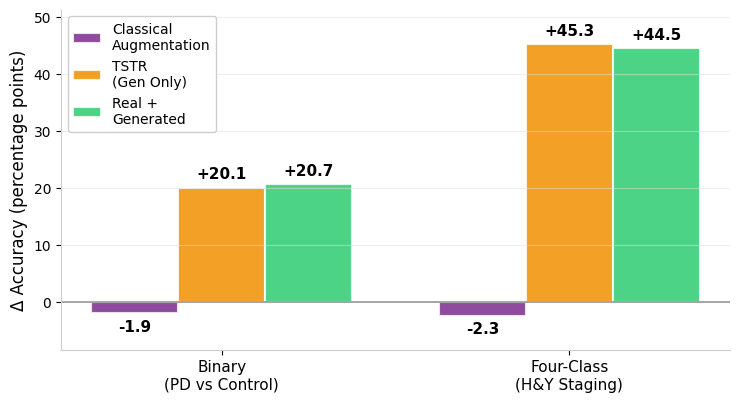


Task                      Condition                      Δ Accuracy
-----------------------------------------------------------------
Binary (PD vs Control)    Classical Augmentation            -1.9 pp
Binary (PD vs Control)    TSTR (Gen Only)                  +20.1 pp
Binary (PD vs Control)    Real + Generated                 +20.7 pp
Four-Class (H&Y Staging)  Classical Augmentation            -2.3 pp
Four-Class (H&Y Staging)  TSTR (Gen Only)                  +45.3 pp
Four-Class (H&Y Staging)  Real + Generated                 +44.5 pp


In [36]:
# Section 5 — Δ accuracy relative to real-only baseline
# Two tasks × three non-baseline conditions = six bars

BG_COLOUR = '#FFFFFF'
GRID_COLOUR = '#E0E0E0'

# Absolute accuracies (%)
binary_baseline   = 64.6
binary_classic    = 62.7
binary_tstr       = 84.7
binary_augmented  = 85.3

fourclass_baseline   = 31.8
fourclass_classic    = 29.5
fourclass_tstr       = 77.1
fourclass_augmented  = 76.3

# Compute deltas (percentage points)
binary_deltas = [binary_classic   - binary_baseline,
                 binary_tstr      - binary_baseline,
                 binary_augmented - binary_baseline]

fourclass_deltas = [fourclass_classic   - fourclass_baseline,
                    fourclass_tstr      - fourclass_baseline,
                    fourclass_augmented - fourclass_baseline]

condition_names = ['Classical\nAugmentation', 'TSTR\n(Gen Only)', 'Real +\nGenerated']
condition_colours = ['#7B2D8E', '#F18F01', '#2ECC71']

tasks = ['Binary\n(PD vs Control)', 'Four-Class\n(H&Y Staging)']
deltas_per_task = np.array([binary_deltas, fourclass_deltas])  # shape (2, 3)

# Plot
SCALE = 0.75
fig, ax = plt.subplots(figsize=(10*SCALE, 5.5*SCALE))
fig.patch.set_facecolor(BG_COLOUR)
ax.set_facecolor(BG_COLOUR)

n_tasks = len(tasks)
n_conditions = len(condition_names)
bar_width = 0.25
x = np.arange(n_tasks)

for i, (name, colour) in enumerate(zip(condition_names, condition_colours)):
    offset = (i - (n_conditions - 1) / 2) * bar_width
    bars = ax.bar(x + offset, deltas_per_task[:, i], bar_width,
                  label=name, color=colour, alpha=0.85,
                  edgecolor='white', linewidth=1.5)

    # Value labels
    for bar, val in zip(bars, deltas_per_task[:, i]):
        # Position label above positive bars, below negative bars
        if val >= 0:
            y_pos = bar.get_height() + 1.0
            va = 'bottom'
        else:
            y_pos = bar.get_height() - 1.0
            va = 'top'
        ax.text(bar.get_x() + bar.get_width() / 2,
                y_pos,
                f'{val:+.1f}',
                ha='center', va=va,
                fontsize=11, fontweight='bold')

# Zero line representing the real-only baseline
ax.axhline(y=0, color='grey', linestyle='-', linewidth=1.2, alpha=0.8)
# ax.text(n_tasks - 0.32, 1.0, 'Real-only baseline',
#         ha='right', va='bottom', fontsize=9, color='grey', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)
ax.set_ylabel('Δ Accuracy (percentage points)', fontsize=12)
# ax.set_title('Change in Accuracy Relative to Real-Only Baseline\n'
#              '(Refer to absolute-accuracy figures for variability)',
#              fontsize=14, fontweight='bold', color='#1B3A5C')

# Symmetric-ish y-limits with headroom for labels
y_min = deltas_per_task.min() - 6
y_max = deltas_per_task.max() + 6
ax.set_ylim(y_min, y_max)

ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.grid(axis='y', color=GRID_COLOUR, linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('cnn_delta_accuracy_summary.png', dpi=900, bbox_inches='tight', facecolor=BG_COLOUR)
plt.show()

# Print a summary table
print(f"\n{'Task':<25s} {'Condition':<25s} {'Δ Accuracy':>15s}")
print("-" * 65)
for task_name, deltas in zip(tasks, [binary_deltas, fourclass_deltas]):
    task_clean = task_name.replace('\n', ' ')
    for cond, delta in zip(condition_names, deltas):
        cond_clean = cond.replace('\n', ' ')
        print(f"{task_clean:<25s} {cond_clean:<25s} {delta:>+12.1f} pp")